# What attributes in Valence, Arousal (Activation) and Dominance

In [89]:
from pathlib import Path

EVAL_DIR = \
[
    #"/Users/elnuralimirzayev/Downloads/IEMOCAP_no_video/IEMOCAP_full_release/Session1/dialog/EmoEvaluation",
    #"/Users/elnuralimirzayev/Downloads/IEMOCAP_no_video/IEMOCAP_full_release/Session2/dialog/EmoEvaluation",
    #"/Users/elnuralimirzayev/Downloads/IEMOCAP_no_video/IEMOCAP_full_release/Session3/dialog/EmoEvaluation",
    #"/Users/elnuralimirzayev/Downloads/IEMOCAP_no_video/IEMOCAP_full_release/Session4/dialog/EmoEvaluation",
    "/Users/elnuralimirzayev/Downloads/IEMOCAP_no_video/IEMOCAP_full_release/Session5/dialog/EmoEvaluation"
]
eval_files = []

for E in EVAL_DIR:
    eval_files += [x for x in Path(E).iterdir() if x.is_file() and not x.name.startswith(".")]
eval_files[0]

PosixPath('/Users/elnuralimirzayev/Downloads/IEMOCAP_no_video/IEMOCAP_full_release/Session5/dialog/EmoEvaluation/Ses05F_script03_2.txt')

In [90]:
import os
import re

eval_lines = []

for eval_file in eval_files:
    with open(eval_file) as f:
        for line in f.readlines():
            if eval_file.stem in line:
                eval_lines.append(line)

ang_evals, hap_evals, sad_evals = [], [], []
for eval in eval_lines:
    eval = eval.split("\t")
    if eval[2] == "ang":
        ang_evals.append(eval)
    elif eval[2] == "hap":
        hap_evals.append(eval)
    elif eval[2] == "sad":
        sad_evals.append(eval)
print(ang_evals)
print(hap_evals)
print(sad_evals)
    

[['[121.2500 - 124.3900]', 'Ses05F_script03_2_F018', 'ang', '[1.5000, 3.5000, 4.0000]\n'], ['[125.2100 - 127.4000]', 'Ses05F_script03_2_F019', 'ang', '[3.0000, 3.0000, 3.5000]\n'], ['[129.2800 - 130.4900]', 'Ses05F_script03_2_F020', 'ang', '[3.0000, 3.0000, 3.0000]\n'], ['[130.5900 - 134.5300]', 'Ses05F_script03_2_F021', 'ang', '[1.0000, 4.0000, 4.5000]\n'], ['[143.8800 - 145.3600]', 'Ses05F_script03_2_F023', 'ang', '[2.5000, 2.5000, 3.0000]\n'], ['[149.6300 - 154.8300]', 'Ses05F_script03_2_F024', 'ang', '[2.0000, 3.0000, 4.5000]\n'], ['[180.5200 - 183.5700]', 'Ses05F_script03_2_F027', 'ang', '[2.5000, 2.0000, 3.0000]\n'], ['[189.1200 - 190.5400]', 'Ses05F_script03_2_F029', 'ang', '[1.5000, 3.5000, 4.0000]\n'], ['[192.4000 - 195.7400]', 'Ses05F_script03_2_F030', 'ang', '[2.5000, 3.5000, 3.5000]\n'], ['[196.8000 - 198.8600]', 'Ses05F_script03_2_F031', 'ang', '[4.0000, 2.5000, 3.5000]\n'], ['[201.5500 - 203.7200]', 'Ses05F_script03_2_F032', 'ang', '[2.0000, 2.5000, 4.0000]\n'], ['[204.79

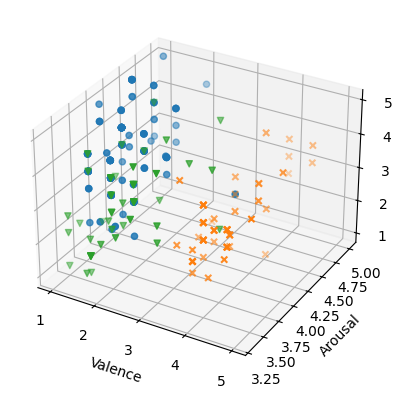

In [91]:
from itertools import count
import numpy as np
from matplotlib import pyplot as plt

def get_vad(eval_list: list):
    vad = []
    for eval in eval_list:
        eval = [float(x) for x in eval[3][1:-2].split(", ")]
        vad.append(eval)
    return np.array(vad)

def plot_vad_dist(ang_vad: list, hap_vad: list, sad_vad: list):
    fig = plt.figure()
    ax = fig.add_subplot(projection='3d')
    ax.scatter(ang_vad[:,0], ang_vad[:,1], ang_vad[:,2], marker='o')
    ax.scatter(hap_vad[:,0], hap_vad[:,1], hap_vad[:,2], marker='x')
    ax.scatter(sad_vad[:,0], sad_vad[:,1], sad_vad[:,2], marker='v')
    ax.set_xlabel('Valence')
    ax.set_ylabel('Arousal')
    ax.set_zlabel('Dominance')
    plt.show()

def filter_low_arousal(vad_list, eval_list):
    new_vad_list, new_eval_list = [], []
    for i, vad in zip(count(), vad_list):
        if vad[1] > 3:
            new_vad_list.append(vad)
            new_eval_list.append(eval_list[i])
    return np.array(new_vad_list), new_eval_list


ang_vad = get_vad(ang_evals)
ang_vad, ang_evals = filter_low_arousal(ang_vad, ang_evals)
hap_vad = get_vad(hap_evals)
hap_vad, hap_evals = filter_low_arousal(hap_vad, hap_evals)
sad_vad = get_vad(sad_evals)
sad_vad, sad_evals = filter_low_arousal(sad_vad, sad_evals)
plot_vad_dist(ang_vad, hap_vad, sad_vad)


In [92]:
ang_vad.shape

(135, 3)

In [93]:
from sklearn import svm

ang_y = np.zeros(len(ang_vad))
hap_y = np.ones(len(hap_vad))
sad_y = np.empty(len(sad_vad))
sad_y.fill(2)
X = np.concatenate((ang_vad, hap_vad, sad_vad), axis=0)
print(X.shape)
Y = np.concatenate((ang_y, hap_y, sad_y))
print(Y.shape)

svc = svm.SVC(kernel='linear').fit(X, Y)

(248, 3)
(248,)


In [94]:
#svc.predict(hap_vad)
y = svc.decision_function(X)
w_norm = np.linalg.norm(svc.coef_)
dist = y / w_norm
print(np.sort(abs(dist)))

[[0.10015335 0.43015214 0.78197991]
 [0.10305037 0.43085518 0.78821828]
 [0.10015335 0.43015214 0.78197991]
 [0.08630244 0.41809592 0.75484505]
 [0.10015458 0.42513435 0.78433893]
 [0.09542483 0.42193545 0.7756503 ]
 [0.10015704 0.42864569 0.78283072]
 [0.09542483 0.42193545 0.7756503 ]
 [0.10305357 0.42413383 0.7899231 ]
 [0.10305118 0.42608738 0.78952624]
 [0.10305357 0.42413383 0.7899231 ]
 [0.10015951 0.4150996  0.78684021]
 [0.09542269 0.42783163 0.77072941]
 [0.09542269 0.42783163 0.77072941]
 [0.09543337 0.40967213 0.78039819]
 [0.09542697 0.41342058 0.77935067]
 [0.08630244 0.41809592 0.75484505]
 [0.09542697 0.41342058 0.77935067]
 [0.10015335 0.43015214 0.78197991]
 [0.09542483 0.42193545 0.7756503 ]
 [0.09543977 0.40527183 0.78136498]
 [0.10015827 0.42306708 0.78503006]
 [0.10015827 0.42306708 0.78503006]
 [0.09542483 0.42193545 0.7756503 ]
 [0.10016073 0.42698066 0.78362209]
 [0.08632075 0.40276261 0.76715645]
 [0.09543337 0.40967213 0.78039819]
 [0.10305357 0.42413383 0.78

In [95]:
dist_abs = abs(dist)
dist_abs = [min(x) for x in dist_abs]
print(dist_abs)
dist_ang = [i for i, x in zip(count(), dist_abs[0:len(ang_vad)])]
dist_hap = [i for i, x in zip(count(), dist_abs[len(ang_vad):len(ang_vad)+len(hap_vad)])]
dist_sad = [i for i, x in zip(count(), dist_abs[-len(sad_vad):])]
print(len(dist_ang))
print(len(dist_hap))
print(len(dist_sad))

[0.10015334866743522, 0.10305037490619534, 0.10015334866743522, 0.08630244159902567, 0.10015458206524105, 0.09542483333158283, 0.1001570406662003, 0.09542483333158283, 0.10305357270631063, 0.10305117574708182, 0.10305357270631063, 0.10015950603708551, 0.09542269360533923, 0.09542269360533923, 0.09543337443049171, 0.09542697259181018, 0.08630244159902567, 0.09542697259181018, 0.10015334866743522, 0.09542483333158283, 0.09543977209765311, 0.10015827345354499, 0.10015827345354499, 0.09542483333158283, 0.10016073083778826, 0.08632075309063202, 0.09543337443049171, 0.10305357270631063, 0.10015827345354499, 0.10015827345354499, 0.10016196301512488, 0.1001570406662003, 0.09885817954452038, 0.09015106004730067, 0.09885624280788469, 0.09543265252542882, 0.09543265252542882, 0.09885430560844498, 0.09542269360533923, 0.10015827345354499, 0.10015334866743522, 0.10016319498880849, 0.09542483333158283, 0.10015211506562324, 0.10015827345354499, 0.10015950603708551, 0.09542483333158283, 0.100152115065

In [96]:
print(ang_evals[9])
print(hap_evals[2])
print(sad_evals[4])

['[231.3600 - 237.4200]', 'Ses05F_script03_2_F039', 'ang', '[1.0000, 4.0000, 5.0000]\n']
['[174.8649 - 182.3262]', 'Ses05F_script01_3_F015', 'hap', '[4.0000, 4.0000, 3.5000]\n']
['[276.8093 - 291.7100]', 'Ses05F_script01_3_M029', 'sad', '[3.5000, 4.0000, 4.0000]\n']


[['/Users/elnuralimirzayev/Downloads/IEMOCAP_no_video/IEMOCAP_full_release/Session5/sentences/wav/Ses05F_script03_2/Ses05F_script03_2_M000.wav', 'As a matter of fact, the real cause of that row was Peter Burden.'], ['/Users/elnuralimirzayev/Downloads/IEMOCAP_no_video/IEMOCAP_full_release/Session5/sentences/wav/Ses05F_script03_2/Ses05F_script03_2_F000.wav', 'You knew there was nothing in that.'], ['/Users/elnuralimirzayev/Downloads/IEMOCAP_no_video/IEMOCAP_full_release/Session5/sentences/wav/Ses05F_script03_2/Ses05F_script03_2_M001.wav', 'I knew nothing of the sort.  You accepted presents from him.'], ['/Users/elnuralimirzayev/Downloads/IEMOCAP_no_video/IEMOCAP_full_release/Session5/sentences/wav/Ses05F_script03_2/Ses05F_script03_2_F001.wav', 'Only a trivial little broach.'], ['/Users/elnuralimirzayev/Downloads/IEMOCAP_no_video/IEMOCAP_full_release/Session5/sentences/wav/Ses05F_script03_2/Ses05F_script03_2_M002.wav', 'I remember it well, covered in diamonds in the worst possible taste.'

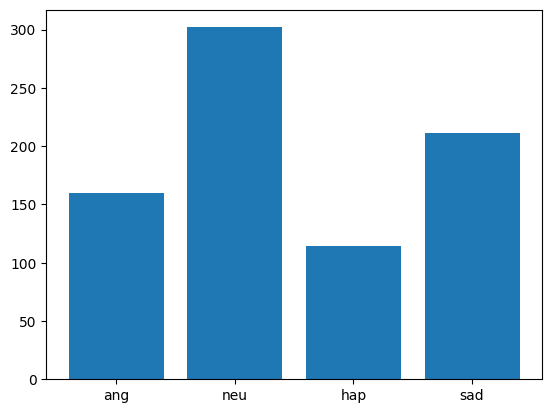

In [97]:
TRANSCRIPTIONS_DIR = "/Users/elnuralimirzayev/Downloads/IEMOCAP_no_video/IEMOCAP_full_release/Session{0}/dialog/transcriptions"
WAVS_DIR = "/Users/elnuralimirzayev/Downloads/IEMOCAP_no_video/IEMOCAP_full_release/Session{0}/sentences/wav"
EMO_EVAL_DIR = "/Users/elnuralimirzayev/Downloads/IEMOCAP_no_video/IEMOCAP_full_release/Session{0}/dialog/EmoEvaluation"
ALLOWED_EMOS = ["ang", "hap", "sad", "neu"]
MIN_WORDS = 3
AUDIOID_MIN_LEN = 3

import os
import re
from matplotlib import pyplot as plt

def get_transcriptions_and_wavfiles(script_dir: str, wav_dir: str):
    txt_files = list(filter(lambda file: \
                            file.endswith(".txt") and not file.startswith("."), \
                            os.listdir(script_dir)))
    sentences_wavs = []
    for file in txt_files:
        with open(os.path.join(script_dir, file)) as f:
            lines = f.readlines()
            for l in lines:
                audio_ref, sent = l.split(":", 1)
                audio_ref = os.path.join(wav_dir, audio_ref.split()[0].rsplit("_", 1)[0], audio_ref.split()[0] + ".wav")
                # Remove existing unknown tags (example: [LAUGHTER])
                sent = re.sub(r"\[(?<=\[)[A-Z]+(?=\])\]", "", sent)
                sent = sent.strip()
                sentences_wavs += [[audio_ref, sent]]
    sentences_wavs = list(filter(lambda item: \
                            len(item[1].split()) >= MIN_WORDS and len(os.path.splitext(os.path.basename(item[0]))[0]) >= AUDIOID_MIN_LEN, sentences_wavs))
    print(sentences_wavs)
    return sentences_wavs

def get_emo_evals(dir: str, pairs: list):
    eval_files = list(filter(lambda file: \
                            file.endswith(".txt") and not file.startswith("."), \
                            os.listdir(dir)))
    all_lines = []
    for file in eval_files:
        with open(os.path.join(dir, file)) as f:
            all_lines += f.readlines()
    for pair in pairs:
        emotion = list(filter(lambda line: os.path.splitext(os.path.basename(pair[0]))[0] in line, all_lines))
        if len(emotion) > 0:
            emotion = emotion[0].split("\t")[2]
            pair.append(emotion)
    return pairs

def filter_allowed_emos(items, allowed_emos):
    return list(filter(lambda item: len(item) == 3 and item[2] in allowed_emos, items))

def plot_emos_distribution(items):
    n_ang = len(filter_allowed_emos(items, ["ang"]))
    n_neu = len(filter_allowed_emos(items, ["neu"]))
    n_hap = len(filter_allowed_emos(items, ["hap"]))
    n_sad = len(filter_allowed_emos(items, ["sad"]))
    print(n_ang, n_neu, n_hap, n_sad)

    plt.bar(["ang", "neu", "hap", "sad"], [n_ang, n_neu, n_hap, n_sad])
    plt.show()

text_wav_pairs = []
for i in range(5, 6):
    text_wav_pairs_i = get_transcriptions_and_wavfiles(TRANSCRIPTIONS_DIR.format(i), WAVS_DIR.format(i))
    text_wav_pairs_i = get_emo_evals(EMO_EVAL_DIR.format(i), text_wav_pairs_i)
    text_wav_pairs += text_wav_pairs_i
print(len(text_wav_pairs))
text_wav_pairs = filter_allowed_emos(text_wav_pairs, ALLOWED_EMOS)
plot_emos_distribution(text_wav_pairs)

['Ses05F_script03_2_F018' 'Ses05F_script03_2_F021'
 'Ses05F_script03_2_F029' 'Ses05F_script03_2_F030'
 'Ses05F_script03_2_F033' 'Ses05F_script03_2_F034'
 'Ses05F_script03_2_F036' 'Ses05F_script03_2_F037'
 'Ses05F_script03_2_F038' 'Ses05F_script03_2_F039'
 'Ses05F_script03_2_F040' 'Ses05F_script03_2_F041'
 'Ses05F_script03_2_M004' 'Ses05F_script03_2_M005'
 'Ses05F_script03_2_M013' 'Ses05F_script03_2_M014'
 'Ses05F_script03_2_M016' 'Ses05F_script03_2_M019'
 'Ses05F_script03_2_M024' 'Ses05F_script03_2_M025'
 'Ses05F_script03_2_M026' 'Ses05F_script03_2_M037'
 'Ses05F_script03_2_M038' 'Ses05F_script03_2_M039'
 'Ses05F_script03_2_M040' 'Ses05F_script03_2_M041'
 'Ses05F_script03_2_M042' 'Ses05F_script03_2_M043'
 'Ses05F_script01_1_F038' 'Ses05F_script01_1_M013'
 'Ses05F_script01_1_M025' 'Ses05F_script01_1_M035'
 'Ses05M_script02_2_F005' 'Ses05M_script02_2_F009'
 'Ses05M_script02_2_F010' 'Ses05M_script02_2_M024'
 'Ses05M_script02_2_M025' 'Ses05M_script02_2_M026'
 'Ses05F_script01_2_F006' 'Ses0

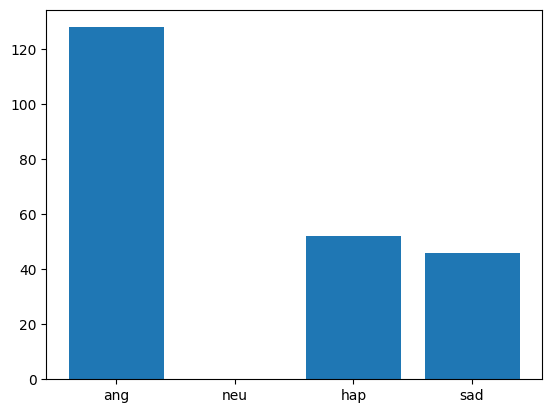

In [98]:
from pathlib import Path

new_pairs = []
all_evals = np.array(ang_evals + hap_evals + sad_evals)[:,1]
print(all_evals)
print(text_wav_pairs)
for pair in text_wav_pairs:
    if Path(pair[0]).stem in all_evals:
        new_pairs.append(pair)
text_wav_pairs = new_pairs
plot_emos_distribution(text_wav_pairs)


In [99]:
# Transform IEMOCAP to LJSPEECH format
import pandas as pd
import shutil as sh

OUTPUT_DIR = "/Users/elnuralimirzayev/Thesis/notebooks/xttsv2_sandbox/iemocap_balanced/train"
OUTPUT_DIR_EVAL = "/Users/elnuralimirzayev/Thesis/notebooks/xttsv2_sandbox/iemocap_balanced/eval"

def map_emo(emo):
    match emo:
        case "neu":
            return "[neu] "
        case "ang":
            return "[ang] "
        case "hap":
            return "[hap] "
        case "sad":
            return "[sad] "

def items_to_metadata(items):
    metadata_list = []
    for item in items:
        emo = map_emo(item[2])
        if emo == "[neu] ":
            emo = ""
        to_add = [os.path.splitext(os.path.basename(item[0]))[0], emo + item[1], emo + item[1]]
        if len(to_add[2]) < 250:
            metadata_list.append(to_add)
    metadata = pd.DataFrame(metadata_list)
    return metadata

def move_audiofiles(items, dir):
    for item in items:
        print(item)
        sh.copy(item[0], os.path.join(dir, "wavs", os.path.basename(item[0])))

def balance_distribution(items):
    df = pd.DataFrame(items)
    ang_df = df[df[2] == "ang"]
    hap_df = df[df[2] == "hap"]
    sad_df = df[df[2] == "sad"]
    max_len = max(len(ang_df), len(hap_df))

    ang_df = pd.concat([ang_df, ang_df.sample(n = max_len - len(ang_df), replace=True)], ignore_index=True)
    hap_df = pd.concat([hap_df, hap_df.sample(n = max_len - len(hap_df), replace=True)], ignore_index=True)
    sad_df = pd.concat([sad_df, sad_df.sample(n = max_len - len(sad_df), replace=True)], ignore_index=True)

    result = pd.concat([ang_df, hap_df, sad_df], ignore_index=True)
    print(result)
    return [list(row[1:]) for row in result.itertuples()]
    

                                                     0  \
0    /Users/elnuralimirzayev/Downloads/IEMOCAP_no_v...   
1    /Users/elnuralimirzayev/Downloads/IEMOCAP_no_v...   
2    /Users/elnuralimirzayev/Downloads/IEMOCAP_no_v...   
3    /Users/elnuralimirzayev/Downloads/IEMOCAP_no_v...   
4    /Users/elnuralimirzayev/Downloads/IEMOCAP_no_v...   
..                                                 ...   
379  /Users/elnuralimirzayev/Downloads/IEMOCAP_no_v...   
380  /Users/elnuralimirzayev/Downloads/IEMOCAP_no_v...   
381  /Users/elnuralimirzayev/Downloads/IEMOCAP_no_v...   
382  /Users/elnuralimirzayev/Downloads/IEMOCAP_no_v...   
383  /Users/elnuralimirzayev/Downloads/IEMOCAP_no_v...   

                                                     1    2  
0    You must admit that he was in love with you, w...  ang  
1             You let him kiss you.  You said you did.  ang  
2    You needn't be so grand simply because you don...  ang  
3                  Oh, that reply has broken my heart. 

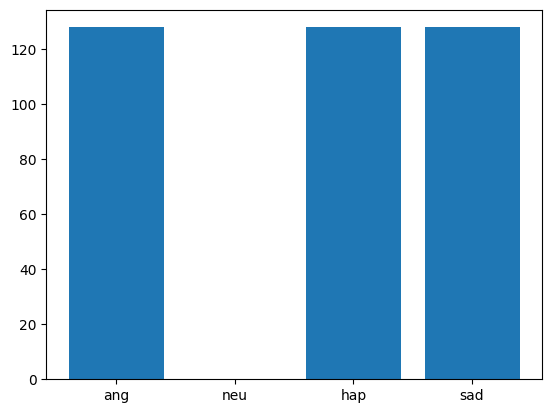

In [100]:
text_wav_pairs = balance_distribution(text_wav_pairs)
plot_emos_distribution(text_wav_pairs)

In [101]:
move_audiofiles(text_wav_pairs, OUTPUT_DIR_EVAL)
metadata_csv = items_to_metadata(text_wav_pairs)
metadata_csv.to_csv(
    "{0}/metadata.csv".format(OUTPUT_DIR_EVAL),
    header=None,
    sep="|",
    index=False
)

['/Users/elnuralimirzayev/Downloads/IEMOCAP_no_video/IEMOCAP_full_release/Session5/sentences/wav/Ses05F_script03_2/Ses05F_script03_2_M004.wav', "You must admit that he was in love with you, wasn't he?", 'ang']
['/Users/elnuralimirzayev/Downloads/IEMOCAP_no_video/IEMOCAP_full_release/Session5/sentences/wav/Ses05F_script03_2/Ses05F_script03_2_M005.wav', 'You let him kiss you.  You said you did.', 'ang']
['/Users/elnuralimirzayev/Downloads/IEMOCAP_no_video/IEMOCAP_full_release/Session5/sentences/wav/Ses05F_script03_2/Ses05F_script03_2_M013.wav', "You needn't be so grand simply because you don't happen to want any at the moment.", 'ang']
['/Users/elnuralimirzayev/Downloads/IEMOCAP_no_video/IEMOCAP_full_release/Session5/sentences/wav/Ses05F_script03_2/Ses05F_script03_2_M016.wav', 'Oh, that reply has broken my heart.', 'ang']
['/Users/elnuralimirzayev/Downloads/IEMOCAP_no_video/IEMOCAP_full_release/Session5/sentences/wav/Ses05F_script03_2/Ses05F_script03_2_M019.wav', "It's a pity you didn't 

In [4]:
import os
import shutil as sh
import random
import pandas as pd

LJ_SPEECH_DIR = "/Users/elnuralimirzayev/Downloads/LJSpeech-1.1"
IEMOCAP_BALANCED_DIR = "/Users/elnuralimirzayev/Thesis/notebooks/xttsv2_sandbox/iemocap_balanced"
LJS_EVAL_SIZE = 1000
LJS_TRAIN_SIZE = 4000

def get_ljspeech_metadata():
    metadata = pd.read_csv(
        os.path.join(LJ_SPEECH_DIR, "metadata.csv"),
        sep="|",
        header=None,
        names=["filename", "text", "normalized_text"]
    )
    return metadata

ljs_metadata = get_ljspeech_metadata()
ljs_metadata = random.sample(list(ljs_metadata.itertuples(index=False)), LJS_TRAIN_SIZE + LJS_EVAL_SIZE)
ljs_eval = ljs_metadata[:LJS_EVAL_SIZE]
ljs_train = ljs_metadata[LJS_EVAL_SIZE:]

def move_ljspeech_audiofiles(items, dir):
    # Append items to existing metadata.csv in iemocap_balanced dir
    metadata_csv = pd.read_csv(
        os.path.join(dir, "metadata.csv"),
        sep="|",
        header=None,
        names=["filename", "text", "normalized_text"]
    )
    metadata_csv = pd.concat([metadata_csv, pd.DataFrame(items)], ignore_index=True)
    metadata_csv.to_csv(
        os.path.join(dir, "metadata.csv"),
        header=None,
        sep="|",
        index=False
    )
    # Append "wavs" from ljspeech dir to iemocap_balanced dir
    for item in items:
        src = os.path.join(LJ_SPEECH_DIR, "wavs", item.filename + ".wav")
        dst = os.path.join(dir, "wavs", item.filename + ".wav")
        sh.copy(src, dst)

move_ljspeech_audiofiles(ljs_eval, os.path.join(IEMOCAP_BALANCED_DIR, "eval"))
move_ljspeech_audiofiles(ljs_train, os.path.join(IEMOCAP_BALANCED_DIR, "train"))